## Top hBN slitghly thinner than bottom 
## Back gate wider than top gate 
## 250 nm cut EBL --> Real one probably 150 nm

## Import the modules you need (this does not need to change)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import glob
import os
import matplotlib.cm as cm
import math as math
import scipy
from scipy import signal
from scipy.fftpack import fft, ifft,fftfreq
from scipy.signal import savgol_filter
from collections import Counter
from ipywidgets import interactive
import ipympl
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA

import time
from mpl_toolkits.mplot3d import Axes3D

import matplotlib 
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.ticker as mticker
#import exportDataToText_v8



class Object():
    pass


plt.rcParams["font.family"] = "arial"
    

## All the functions for plotting are in here

In [2]:
import LDQM_dataplot

importlib.reload(LDQM_dataplot)

savename='C:/Users/jdiez/LDQM/a. Data/Ju1/Fig/'
savename='C:/jdiez_local/LDQM/g. Manuscript/Ju1/Figures_2022/'
savecount=1


In [3]:
import LDQM_dataplot
import Superconductor_analysis
import TB32_Ic_analysis
import homemade_functions 
import JJ_current_distribution

savename='C:/Users/jdiez/LDQM/a. Data/Ju1/Fig/'
savecount=1


orig_cmap = matplotlib.cm.RdBu_r
mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

font=16

def update_modules():
    
    importlib.reload(LDQM_dataplot)
    importlib.reload(Superconductor_analysis)
    importlib.reload(TB32_Ic_analysis)
    importlib.reload(homemade_functions)
    importlib.reload(JJ_current_distribution)

C:\jdiez_local\.jupyter\LDQM_dataplot.py:768: UserWarning: Trying to register the cmap 'shiftedcmap' which already exists.
  plt.register_cmap(cmap=newcmap)


In [34]:
update_modules()

from homemade_functions import runningMeanFast
from homemade_functions import plot_pre,plot_map,plot_line
from Superconductor_analysis import parula_cmap as parula
from Superconductor_analysis import derivative_dvdi, Ic_derivative 
from Superconductor_analysis import get_Ic_minimum, map_interpolation, magnJJ_bulk_edge,magnJJ_bulkedge
from Superconductor_analysis import get_Ic_maximums as get_Ic_max


## Functions to extract the data from the hdf5 are in here

# Import the MatLab files

In [5]:
import scipy.io

In [6]:
folder='C:/jdiez_local/LDQM/e. Simulations/Yinming_TBGJJ/Data_Summary/'



In [7]:
 mat_fig2b=scipy.io.loadmat(folder+'FIG2/FIG2b.mat')

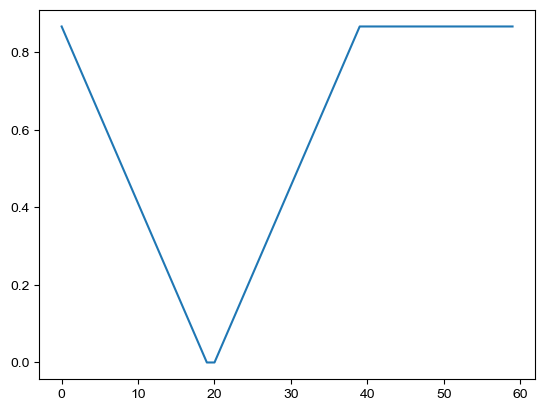

In [40]:
plt.plot(mat_fig2b['k_path_x'][0])

In [36]:
%matplotlib inline

(0.0, 59.0)

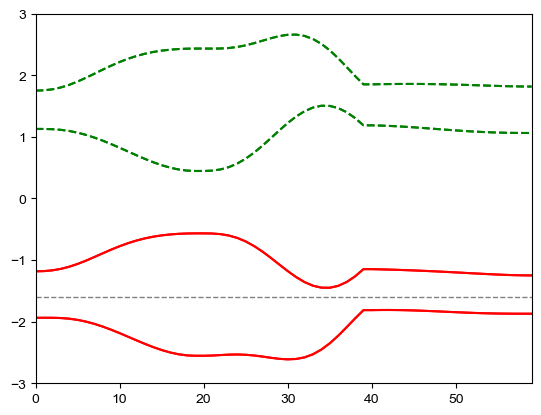

In [37]:

for i in range(0,4):
    plt.plot(mat_fig2b['E'][i],'r')
for i in range(4,8):
    plt.plot(mat_fig2b['E'][i],'g--')
plt.plot(np.linspace(0,60,101),np.linspace(0,60,101)*0-1.6,linestyle='dashed',linewidth=1,color='gray')
plt.ylim(-3,3) 
plt.xlim(0,59)


(0.0, 59.0)

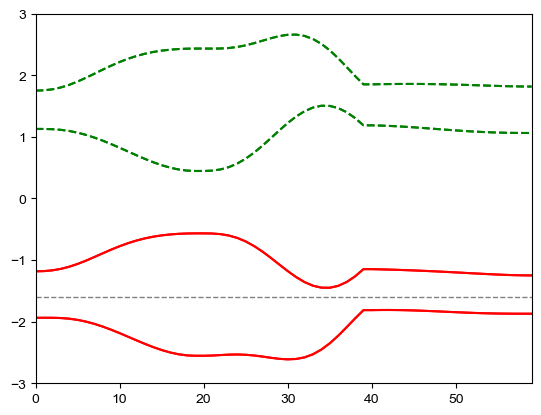

In [41]:
for i in range(0,4):
    plt.plot(mat_fig2b['E'][i],'r')
for i in range(4,8):
    plt.plot(mat_fig2b['E'][i],'g--')
plt.plot(np.linspace(0,60,101),np.linspace(0,60,101)*0-1.6,linestyle='dashed',linewidth=1,color='gray')
plt.ylim(-3,3) 
plt.xlim(0,59)

In [17]:
folder

'W:/a. Members/Jaime/e. Simulations/Yinming_TBGJJ/Data_Summary/'

In [42]:
#folder='W:/a. Members/Jaime/e. Simulations/Yinming_TBGJJ/Data_Summary/'
mat_fig3d1=scipy.io.loadmat(folder+'FIG3/7_27_M_vp_p_0_8.mat')
mat_fig3d2=scipy.io.loadmat(folder+'FIG3/7_27_M_vp_m_0_8.mat')

In [44]:
mat_fig3d1

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Tue Jul 27 19:40:07 2021',
 '__version__': '1.0',
 '__globals__': [],
 'ConPara': array([[(array([[1]], dtype=uint8),)]], dtype=[('tc', 'O')]),
 'Flux': array([[-3. , -2.8, -2.6, -2.4, -2.2, -2. , -1.8, -1.6, -1.4, -1.2, -1. ,
         -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2,
          1.4,  1.6,  1.8,  2. ,  2.2,  2.4,  2.6,  2.8,  3. ]]),
 'Flux_temp': array([[3]], dtype=uint8),
 'HamPara': array([[(array([[0.1]]), array([[0.331]]), array([[-0.01]]), array([[0.097]]), array([[-0.5]]), array([[0]], dtype=uint8), array([[0.8]]), array([[-0.9]]), array([[1.57079633]]), array([[0.0662]]), array([[0.0331]]), array([[1.57079633]]), array([[80]], dtype=uint8), array([[9]], dtype=uint8), array([[0]], dtype=uint8), array([[0]], dtype=uint8), array([[0]], dtype=uint8), array([[1]], dtype=uint8), array([[-0.01231997, -0.01170397, -0.01108797, -0.01047198, -0.00985598,
                 -0.00923998, -0.0

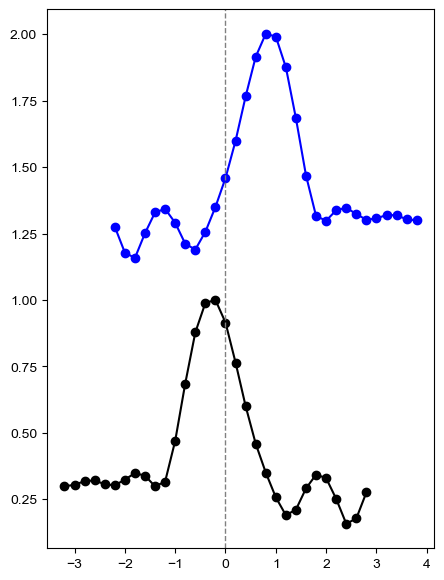

In [45]:
plt.figure(figsize=(5,7))
plt.plot(mat_fig3d1['Flux'][0]+0.8,mat_fig3d1['I_p'][0]/2.5+1,'bo-')
plt.plot(mat_fig3d2['Flux'][0]-0.2,mat_fig3d2['I_p'][0]/2.5,'ko-')
plt.axvline(x=0,linestyle='dashed',linewidth=1,color='gray')

In [114]:
savecount=0

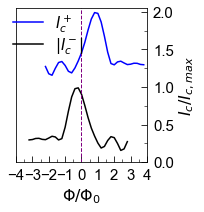

In [375]:

cm = 1/2.54  # centimeters in inches

if savecount==0:
    save=True
else:
    save=False 
# Fig params to save and color 

# terrain looks cool
orig_cmap = matplotlib.cm.RdBu_r
#orig_cmap = parula_map
mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap,start=0,stop=1)

# Start the figure 

fig=plt.figure(figsize=(12*cm*2,4*cm*2))
gridx=40
gridy=80
gs=matplotlib.gridspec.GridSpec(gridx,gridy)
msize=12
count=0

#The extracted Ic

ax2=fig.add_subplot(gs[0:36,60:80])


ax2.plot(mat_fig3d1['Flux'][0]+0.8,mat_fig3d1['I_p'][0]/2.53+1,'b-',label='$I_c^+$',markersize=msize)
ax2.plot(mat_fig3d2['Flux'][0]-0.2,mat_fig3d2['I_p'][0]/2.53,'k-',label='$|I_c^-|$',markersize=msize)
ax2.set_xlim(-4,4)
ax2.set_ylim(0,2.05)
#plt.title('$n_{JJ}:$'+'{0:.2f}'.format(n_JJ2)+'$x10^{-12}$ cm$^{-2}$ , $V_{BG}$:'+str(Vbg)+' V, $T=500$ mK ',fontsize=font)
ax2.legend(loc='upper center', bbox_to_anchor=(0.25, 1.06), shadow=False, ncol=1,fontsize=font,
           labelspacing=0.1,frameon=False)
ax2.set_xlabel('$\Phi/\Phi_0$',fontsize=font+1)
ax2.set_ylabel('$I_c/I_{c,max}$',fontsize=font+1)
ax2.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=tickpad,size=6)
ax2.tick_params(axis='both',which='minor',direction='in',size=3)
ax2.tick_params(axis='y',which='both',labelleft=False,labelright=True,left=False,right=True)

ax2.yaxis.set_label_position("right")
ax2.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.5))
ax2.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax2.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.25))

ax2.axvline(x=0,color='purple',linewidth=1,linestyle='dashed')
#ax2.plot(np.linspace(-7,10,101),np.linspace(20,6,101),linestyle='dashed',linewidth=1,color='darkturquoise')


if save:
    plt.savefig(savename+'ValleyPolarizedTheory'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=600,bbox_inches='tight') 
    savecount=savecount+1
    
plt.show()

NameError: name 'font' is not defined

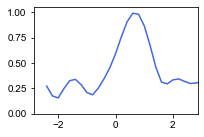

In [21]:

cm = 1/2.54  # centimeters in inches

if savecount==0:
    save=True
else:
    save=False 
# Fig params to save and color 

# terrain looks cool
orig_cmap = matplotlib.cm.RdBu_r
#orig_cmap = parula_map
mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap,start=0,stop=1)

# Start the figure 

fig=plt.figure(figsize=(12*cm*2,4*cm*2))
gridx=40
gridy=80
gs=matplotlib.gridspec.GridSpec(gridx,gridy)
msize=12
count=0

#The extracted Ic

ax2=fig.add_subplot(gs[0:25,0:25])


ax2.plot(mat_fig3d1['Flux'][0]+0.4+0.2,mat_fig3d1['I_p'][0]/2.53,'royalblue',label='$I_c^+$',markersize=msize)
#plt.plot(-yT[num][:,0],-Ic_negT[num],'k--',label='$|I_c^- (-B)|$',markersize=msize)
ax2.set_xlim(-10/3.5,10/3.5)
ax2.set_ylim(0,1.05)
#plt.title('$n_{JJ}:$'+'{0:.2f}'.format(n_JJ2)+'$x10^{-12}$ cm$^{-2}$ , $V_{BG}$:'+str(Vbg)+' V, $T=500$ mK ',fontsize=font)
#ax2.legend(loc='upper center', bbox_to_anchor=(0.25, 1.06), shadow=False, ncol=1,fontsize=font,
 #          labelspacing=0.1,frameon=False)
ax2.set_xlabel('$\Phi/\Phi_0$ ',fontsize=font+1)
ax2.set_ylabel('$I_c/I_{c,max}$',fontsize=font+1)
ax2.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=tickpad,size=6)
ax2.tick_params(axis='both',which='minor',direction='in',size=3)
ax2.tick_params(axis='y',which='both',labelleft=False,labelright=True,left=False,right=True)
#ax2.tick_params(axis='x',which='both',labelbottom=False)
ax2.yaxis.set_label_position("right")
ax2.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax2.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax2.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax2.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.25))

ax2.axvline(x=0,color='silver',linewidth=1,linestyle='dashed')
#ax2.plot(np.linspace(-7,10,101),np.linspace(20,6,101),linestyle='dashed',linewidth=1,color='darkturquoise')

ax3=fig.add_subplot(gs[0:25,35:60])


ax3.plot(mat_fig3d2['Flux'][0]+0.4-0.2,mat_fig3d2['I_p'][0]/2.53,'k-',label='$|I_c^-|$',markersize=msize)
ax3.plot(mat_fig3d2['Flux'][0]+0.4+0.2,mat_fig3d1['I_p'][0]/2.53,'royalblue',label='$|I_c^- (-B)|$',markersize=msize)
ax3.set_xlim(-10/3.5,10/3.5)
ax3.set_ylim(0,1.05)
#plt.title('$n_{JJ}:$'+'{0:.2f}'.format(n_JJ2)+'$x10^{-12}$ cm$^{-2}$ , $V_{BG}$:'+str(Vbg)+' V, $T=500$ mK ',fontsize=font)
#ax3.legend(loc='upper center', bbox_to_anchor=(0.25, 1.06), shadow=False, ncol=1,fontsize=font,
#           labelspacing=0.1,frameon=False)
ax3.set_xlabel('$\Phi/\Phi_0$ ',fontsize=font+1)
ax3.set_ylabel('$I_c/I_{c,max}$',fontsize=font+1)
ax3.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=tickpad,size=6)
ax3.tick_params(axis='both',which='minor',direction='in',size=3)
ax3.tick_params(axis='y',which='both',labelleft=False,labelright=True,left=False,right=True)
ax3.yaxis.set_label_position("right")

ax3.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax3.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax3.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax3.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.25))

ax3.axvline(x=0,color='silver',linewidth=1,linestyle='dashed')
#ax2.plot(np.linspace(-7,10,101),np.linspace(20,6,101),linestyle='dashed',linewidth=1,color='darkturquoise')


if save:
    plt.savefig(savename+'ValleyPolarizedTheory_shiftedlikeexp'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=600,bbox_inches='tight') 
    savecount=savecount+1
    
plt.show()

In [369]:
savecount=0

In [110]:
savename='W:/a. Members/Jaime/g. Manuscript/Figures/'

In [378]:
 mat_fig2d=scipy.io.loadmat(folder+'FIG2/FIG2d.mat')

In [161]:
mat_fig2d

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Wed Aug 18 20:47:15 2021',
 '__version__': '1.0',
 '__globals__': [],
 'Berry_cur': array([[7.41253599, 7.40431297, 7.38119719, ..., 7.37412367, 7.40090859,
         7.41253599],
        [7.41121252, 7.40686681, 7.38662442, ..., 7.37986935, 7.40362521,
         7.41121252],
        [7.40565657, 7.40453098, 7.38647587, ..., 7.38005086, 7.4014573 ,
         7.40565657],
        ...,
        [5.09595222, 5.09621113, 5.09109174, ..., 5.08852999, 5.09500539,
         5.09595222],
        [5.09849737, 5.09785158, 5.09234876, ..., 5.08961496, 5.09655899,
         5.09849737],
        [5.09964239, 5.09778138, 5.09155991, ..., 5.08865823, 5.09640385,
         5.09964239]]),
 'Berry_cur_t': array([[6.47730848]]),
 'Chern_N': array([[1.03089566]]),
 'D': array([[-1.94708529],
        [-1.92708529],
        [-1.19291471],
        [-1.17291471],
        [ 1.11911471],
        [ 1.13911471],
        [ 1.74088529],
        [ 1.76088

In [22]:
import cmath

In [23]:
mod_orbital=np.zeros_like(mat_fig2d['M_orbit'])

NameError: name 'mat_fig2d' is not defined

In [180]:
cmath.polar(mat_fig2d['M_orbit'][i,j])

(118.48358555909469, 3.141592653589793)

In [382]:
# Get the modulus of the complex number
for i in range(len(mat_fig2d['M_orbit'])):
    for j in range(len(mat_fig2d['M_orbit'][0])):
        mod_orbital[i,j]=cmath.polar(mat_fig2d['M_orbit'][i,j])[0]

(-0.8660254037844386, 0.8660254037844386, -1.0, 1.0)

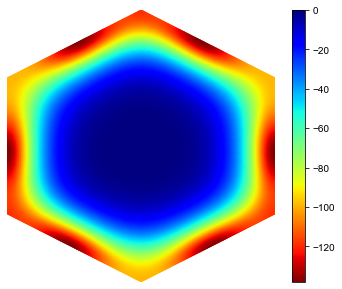

In [380]:
plt.figure(figsize=(6,5))
plt.pcolormesh(mat_fig2d['X'],mat_fig2d['Y'],mat_fig2d['M_orbit'].real,cmap='jet_r',shading='gouraud')
plt.colorbar()
plt.axis('off')

In [373]:
mat_fig2d['K_m']

KeyError: 'K_m'

In [407]:
savecount=0

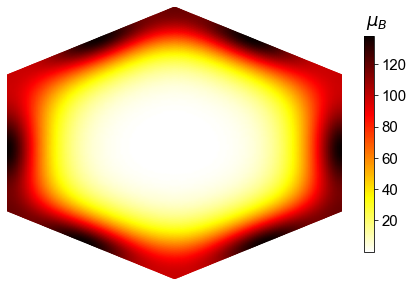

In [408]:
if savecount==0:
    save=True
else:
    save=False
    
fig = plt.figure(figsize=(6,5))

ax = plt.subplot(111)
im=plt.pcolormesh(mat_fig2d['X'],mat_fig2d['Y'],mod_orbital.real,cmap='hot_r',shading='gouraud')
### Add the colorbar 

ax.tick_params(axis='both', which='major', labelsize=font)

### Add the colorbar 
cbaxes = fig.add_axes([0.95, 0.2, 0.025,0.6]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='vertical') 

#cb=plt.colorbar(pad=0)
cb.set_label('$\mu_B$',fontsize=18,position=(0.7,1.1), labelpad=-30,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

ax.axis('off')

if save:
    plt.savefig(savename+'Magnetization_invertmass'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=600,bbox_inches='tight') 
    savecount=savecount+1

# Spin part of the simulationn 

In [81]:
folder

'W:/a. Members/Jaime/e. Simulations/Yinming_TBGJJ/Data_Summary/'

In [85]:
 mat_fig4c=scipy.io.loadmat(folder+'FIG4/FIG4c.mat')

In [25]:
mat_fig4c

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Wed Jul 28 21:23:36 2021',
 '__version__': '1.0',
 '__globals__': [],
 'ConPara': array([[(array([[1]], dtype=uint8),)]], dtype=[('tc', 'O')]),
 'Flux': array([[-3.  , -2.88, -2.76, -2.64, -2.52, -2.4 , -2.28, -2.16, -2.04,
         -1.92, -1.8 , -1.68, -1.56, -1.44, -1.32, -1.2 , -1.08, -0.96,
         -0.84, -0.72, -0.6 , -0.48, -0.36, -0.24, -0.12,  0.  ,  0.12,
          0.24,  0.36,  0.48,  0.6 ,  0.72,  0.84,  0.96,  1.08,  1.2 ,
          1.32,  1.44,  1.56,  1.68,  1.8 ,  1.92,  2.04,  2.16,  2.28,
          2.4 ,  2.52,  2.64,  2.76,  2.88,  3.  ]]),
 'Flux_temp': array([[3]], dtype=uint8),
 'HamPara': array([[(array([[0.1]]), array([[0.331]]), array([[-0.01]]), array([[0.097]]), array([[-0.5]]), array([[0.1]]), array([[0.8]]), array([[-0.9]]), array([[1.57079633]]), array([[0.0662]]), array([[0.0331]]), array([[1.57079633]]), array([[100]], dtype=uint8), array([[9]], dtype=uint8), array([[0]], dtype=uint8), 

In [115]:
savecount=0

In [31]:
font=20
tickpad=6

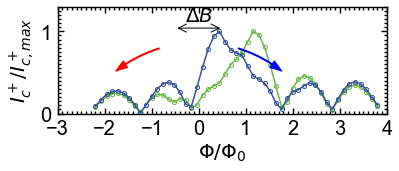

In [116]:
if savecount==0:
    save=True
    savecount=savecount+1
else:
    save=False
    
fig=plt.figure(figsize=(12*cm*2,4*cm*2))
gridx=40
gridy=80
gs=matplotlib.gridspec.GridSpec(gridx,gridy)
msize=12
count=0

#The extracted Ic

ax2=fig.add_subplot(gs[0:25,30:80])

ax2.plot(mat_fig4c['Flux'][0]+0.8,mat_fig4c['I_p'][0]/np.amax(mat_fig4c['I_p'][0]),'o-',color=[102/255,184/255,69/255],markerfacecolor='none',markersize=4)
ax2.plot(mat_fig4c['Flux'][0]+0.8,mat_fig4c['I_p'][1]/np.amax(mat_fig4c['I_p'][1]),'o-',color=[53/255,79/255,161/255],markerfacecolor='none',markersize=4)


ax2.set_xlabel('$\Phi/\Phi_0$',fontsize=font)
ax2.set_ylabel('$I_c^+/I_{c,max}^+$',fontsize=font)

ax2.set_ylim(0,1.3)  
ax2.set_xlim(-3,4)

ax2.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=6,width=1.4)
ax2.tick_params(axis='both',which='minor',direction='in',size=3,width=1.4,pad=6)

ax2.tick_params(axis='x',which='both', bottom=True,top=True,labelbottom=True)
ax2.tick_params(axis='y',which='both', left=True,right=True)

ax2.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
ax2.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
ax2.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(1.4)
    
#ax2.set_xticks([-15,-10,-5,0,5,10,15])
#ax2.set_yticks([-0,20,40,60])

ax2.text(-0.3,1.12,'$\Delta B$',fontsize=font)

ax2.annotate('', xy=(-0.5,1.04),
            xytext=(0.5,1.04),
            arrowprops=dict(facecolor='black',arrowstyle='<->'),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )

ax2.annotate('', xy=(1.8,0.5),
            xytext=(0.8,0.8),
            arrowprops=dict(color='b',arrowstyle="Simple, tail_width=0.05, head_width=0.4, head_length=0.6"
                            ,connectionstyle="arc3,rad=-0.1"),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
ax2.annotate('', xy=(-1.8,0.5),
            xytext=(-0.8,0.8),
            arrowprops=dict(color='r',arrowstyle="Simple, tail_width=0.05, head_width=0.4, head_length=0.6"
                            ,connectionstyle="arc3,rad=0.1"),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )


if save:
    plt.savefig(savename+'SpinPolarizedTheoryc_vscience'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=600,bbox_inches='tight') 
    savecount=savecount+1
    
plt.show()

In [83]:
 mat_fig4b=scipy.io.loadmat(folder+'FIG4/FIG4b.mat')
    

In [109]:
savecount=0

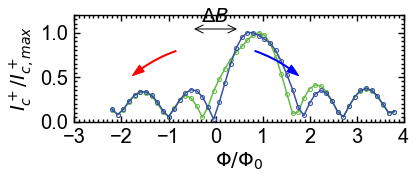

In [110]:
if savecount==0:
    save=True
    savecount=savecount+1
else:
    save=False
    
fig=plt.figure(figsize=(12*cm*2,4*cm*2))
gridx=40
gridy=80
gs=matplotlib.gridspec.GridSpec(gridx,gridy)
msize=12
count=0

#The extracted Ic

ax2=fig.add_subplot(gs[0:25,30:80])

ax2.plot(mat_fig4b['Flux'][0]+0.8,mat_fig4b['I_p'][0]/np.amax(mat_fig4b['I_p'][0]),'o-',color=[102/255,184/255,69/255],markerfacecolor='none',markersize=4)
ax2.plot(mat_fig4b['Flux'][0]+0.8,mat_fig4b['I_p'][1]/np.amax(mat_fig4b['I_p'][1]),'o-',color=[53/255,79/255,161/255],markerfacecolor='none',markersize=4)


ax2.set_xlabel('$\Phi/\Phi_0$',fontsize=font)
ax2.set_ylabel('$I_c^+/I_{c,max}^+$',fontsize=font)

ax2.set_ylim(0,1.2)  
ax2.set_xlim(-3,4)

ax2.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=6,width=1.4)
ax2.tick_params(axis='both',which='minor',direction='in',size=3,width=1.4,pad=6)

ax2.tick_params(axis='x',which='both', bottom=True,top=True,labelbottom=True)
ax2.tick_params(axis='y',which='both', left=True,right=True)
ax2.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
ax2.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
ax2.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
ax2.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))

for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(1.4)
    
#ax2.set_xticks([-15,-10,-5,0,5,10,15])
#ax2.set_yticks([-0,20,40,60])

ax2.text(-0.3,1.12,'$\Delta B$',fontsize=font)

ax2.annotate('', xy=(-0.5,1.04),
            xytext=(0.5,1.04),
            arrowprops=dict(facecolor='black',arrowstyle='<->'),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )

ax2.annotate('', xy=(1.8,0.5),
            xytext=(0.8,0.8),
            arrowprops=dict(color='b',arrowstyle="Simple, tail_width=0.05, head_width=0.4, head_length=0.6"
                            ,connectionstyle="arc3,rad=-0.1"),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
ax2.annotate('', xy=(-1.8,0.5),
            xytext=(-0.8,0.8),
            arrowprops=dict(color='r',arrowstyle="Simple, tail_width=0.05, head_width=0.4, head_length=0.6"
                            ,connectionstyle="arc3,rad=0.1"),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )


if save:
    plt.savefig(savename+'SpinPolarizedTheoryb_vscience'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=600,bbox_inches='tight') 
    savecount=savecount+1
    
plt.show()

In [42]:
savename='W:/a. Members/Jaime/g. Manuscript/Figures_SI/'

# Other valley polarization 

In [386]:
folder2='W:/a. Members/Jaime/f. Simulations/Yinming_TBGJJ/Oppsite_valley_polarization/'

In [393]:
 mat_oppvalley=scipy.io.loadmat(folder2+'band_TBG_M_vp_1_5.mat')
mat_oppvalley_mag=scipy.io.loadmat(folder2+'orbit_M_vp_1_5meV.mat')

In [390]:
savecount=1

(0.0, 59.0)

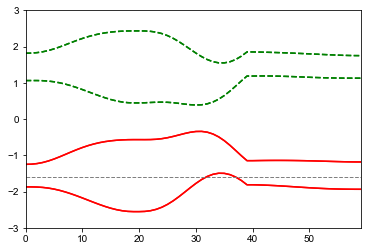

In [403]:
for i in range(0,4):
    plt.plot(mat_oppvalley['E'][i],'r')
for i in range(4,8):
    plt.plot(mat_oppvalley['E'][i],'g--')
plt.plot(np.linspace(0,60,101),np.linspace(0,60,101)*0-1.6,linestyle='dashed',linewidth=1,color='gray')
plt.ylim(-3,3) 
plt.xlim(0,59)

In [395]:
mat_oppvalley_mag

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Wed Aug 25 17:33:18 2021',
 '__version__': '1.0',
 '__globals__': [],
 'D': array([[-1.89088529],
        [-1.85088529],
        [-1.26911471],
        [-1.22911471],
        [ 1.04291471],
        [ 1.08291471],
        [ 1.79708529],
        [ 1.83708529]]),
 'E': array([[-1.89088529],
        [-1.85088529],
        [-1.26911471],
        [-1.22911471],
        [ 1.04291471],
        [ 1.08291471],
        [ 1.79708529],
        [ 1.83708529]]),
 'I': array([[7],
        [3],
        [8],
        [4],
        [6],
        [2],
        [5],
        [1]], dtype=uint8),
 'K': array([[4.1887902]]),
 'M_orbit': array([[ 97.68295089+1.12130818e-85j,  97.64969862-1.13513760e-14j,
          97.56009309+3.03788048e-51j, ...,  97.50643733+4.53853324e-14j,
          97.62434443+3.40541280e-14j,  97.68295089+1.41477750e-79j],
        [ 97.68019544-1.51370836e-14j,  97.66160683+2.27034089e-14j,
          97.57947792-3.78240452e-

In [398]:
mod_orbital2=np.zeros_like(mat_fig2d['M_orbit'])

In [180]:
cmath.polar(mat_fig2d['M_orbit'][i,j])

(118.48358555909469, 3.141592653589793)

In [400]:
# Get the modulus of the complex number
for i in range(len(mat_oppvalley_mag['M_orbit'])):
    for j in range(len(mat_oppvalley_mag['M_orbit'][0])):
        mod_orbital2[i,j]=cmath.polar(mat_oppvalley_mag['M_orbit'][i,j])[0]

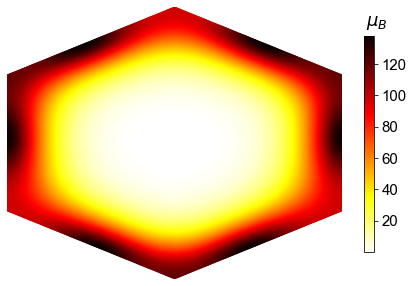

In [406]:
if savecount==0:
    save=True
else:
    save=False
    
fig = plt.figure(figsize=(6,5))

ax = plt.subplot(111)
im=plt.pcolormesh(mat_oppvalley_mag['X'],mat_oppvalley_mag['Y'],mod_orbital2.real,cmap='hot_r',shading='gouraud')
### Add the colorbar 

ax.tick_params(axis='both', which='major', labelsize=font)

### Add the colorbar 
cbaxes = fig.add_axes([0.95, 0.2, 0.025,0.6]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='vertical') 

#cb=plt.colorbar(pad=0)
cb.set_label('$\mu_B$',fontsize=18,position=(0.7,1.1), labelpad=-30,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

ax.axis('off')

if save:
    plt.savefig(savename+'MagOppValley'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=600,bbox_inches='tight') 
    savecount=savecount+1

In [405]:
savecount=0

# Assemble FIg 3 

In [4166]:
savename='W:/a. Members/Jaime/g. Manuscript/Figures/'

In [264]:
savecount=0

In [210]:
savename='W:/a. Members/Jaime/g. Manuscript/Figures/'

In [ ]:
savename

In [4390]:
pos_coerc[0]

7.000000000000013

# 27/09 New data 

In [419]:
folder

'W:/a. Members/Jaime/e. Simulations/Yinming_TBGJJ/Data_Summary/'

In [420]:
folder3='W:/a. Members/Jaime/e. Simulations/Yinming_TBGJJ/9_26_to_Jaime/'

In [421]:
mat_novalley=scipy.io.loadmat(folder3+'with_orbital_moment_FP/M_vp_p_1_large_range_without_orbital_magnetic_moment.mat')
mat_largevalley_pos=scipy.io.loadmat(folder3+'with_orbital_moment_FP/orbital_M_vp_m_1.mat')
mat_largevalley_neg=scipy.io.loadmat(folder3+'with_orbital_moment_FP/orbital_M_vp_p_1.mat')

In [426]:
mat_novalley

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sat Sep 25 03:21:16 2021',
 '__version__': '1.0',
 '__globals__': [],
 'ConPara': array([[(array([[1]], dtype=uint8),)]], dtype=[('tc', 'O')]),
 'Flux': array([[-5. , -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4.3, -4.2, -4.1, -4. ,
         -3.9, -3.8, -3.7, -3.6, -3.5, -3.4, -3.3, -3.2, -3.1, -3. , -2.9,
         -2.8, -2.7, -2.6, -2.5, -2.4, -2.3, -2.2, -2.1, -2. , -1.9, -1.8,
         -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1. , -0.9, -0.8, -0.7,
         -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,
          0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,  1.2,  1.3,  1.4,  1.5,
          1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,  2.3,  2.4,  2.5,  2.6,
          2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,  3.4,  3.5,  3.6,  3.7,
          3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,  4.5,  4.6,  4.7,  4.8,
          4.9,  5. ]]),
 'Flux_temp': array([[5]], dtype=uint8),
 'HamPara': array([[(array([[0.1]]), ar

In [478]:
save=True

NameError: name 'mat_novalley' is not defined

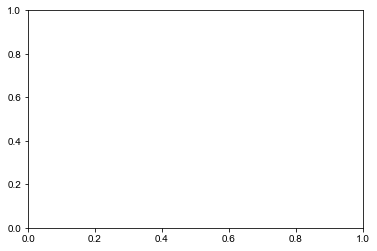

In [30]:
fig=plt.figure(figsize=(6,4))
ax=plt.subplot(111)

ax.plot(mat_novalley['Flux'][0],mat_novalley['I_p'][0]/0.37,'bo-',fillstyle='none',markeredgewidth=2)

ax.set_xlabel('$\Phi/\Phi_0$',fontsize=font+2)
ax2.set_ylabel('$I_c^+/I_{c,max}^+$ (nA)',fontsize=font+2)
ax.set_ylim(0,1.1)
ax.set_xlim(-4,4)
#ax2.text(15,54,'$T=35$ mK',fontsize=18)  
ax.tick_params(axis='both', which='major', labelsize=font+1,direction='in')
ax.tick_params(axis='x',which='both', bottom=True,top=False,labelbottom=True)
ax.tick_params(axis='y',which='both', left=True,right=False,labelleft=True)
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))

if save:
    plt.savefig(savename+'noVP_halffilling'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=300) 
    save=False
plt.show()

plt.plot(mat_largevalley_pos['Flux'][0],mat_largevalley_pos['I_p'][0])
plt.plot(mat_largevalley_neg['Flux'][0],mat_largevalley_neg['I_p'][0])

In [437]:
mat_oppvalley_mag2=scipy.io.loadmat(folder3+'orbit_magnetic_moment_in_BZ/orbit_M_vp_1_5meV.mat')

In [439]:
mod_orbital3=np.zeros_like(mat_oppvalley_mag2['M_orbit'])

In [445]:
# Get the modulus of the complex number
for i in range(len(mat_oppvalley_mag2['M_orbit'])):
    for j in range(len(mat_oppvalley_mag2['M_orbit'][0])):
        mod_orbital3[i,j]=cmath.polar(mat_oppvalley_mag2['M_orbit'][i,j])[0]

In [447]:
mod_orbital3

array([[ 97.68295089+0.j,  97.64969862+0.j,  97.56009309+0.j, ...,
         97.50643733+0.j,  97.62434443+0.j,  97.68295089+0.j],
       [ 97.68019544+0.j,  97.66160683+0.j,  97.57947792+0.j, ...,
         97.5291548 +0.j,  97.6379353 +0.j,  97.68019544+0.j],
       [ 97.65999942+0.j,  97.65178615+0.j,  97.57247912+0.j, ...,
         97.52556132+0.j,  97.6298304 +0.j,  97.65999942+0.j],
       ...,
       [119.79985218+0.j, 119.82396337+0.j, 119.67417879+0.j, ...,
        119.56684316+0.j, 119.77249963+0.j, 119.79985218+0.j],
       [119.88512283+0.j, 119.87636188+0.j, 119.70579091+0.j, ...,
        119.59328545+0.j, 119.82227444+0.j, 119.88512283+0.j],
       [119.9250564 +0.j, 119.87566504+0.j, 119.67611519+0.j, ...,
        119.55860083+0.j, 119.81902614+0.j, 119.9250564 +0.j]])

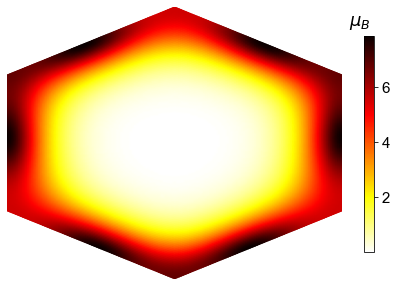

In [451]:
if savecount==0:
    save=True
else:
    save=False
K_fact= 4*np.pi/3
fig = plt.figure(figsize=(6,5))

ax = plt.subplot(111)
im=plt.pcolormesh(mat_oppvalley_mag2['X'],mat_oppvalley_mag2['Y'],mod_orbital3.real/(K_fact)**2,cmap='hot_r',shading='gouraud')
### Add the colorbar 

ax.tick_params(axis='both', which='major', labelsize=font)

### Add the colorbar 
cbaxes = fig.add_axes([0.95, 0.2, 0.025,0.6]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='vertical') 

#cb=plt.colorbar(pad=0)
cb.set_label('$\mu_B$',fontsize=18,position=(0.7,1.1), labelpad=-30,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

ax.axis('off')

if save:
    plt.savefig(savename+'MagOppValley'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=600,bbox_inches='tight') 
    savecount=savecount+1
plt.show()

In [450]:
savecount=0

# Last figure of the SI

In [118]:
folder4='W:/a. Members/Jaime/e. Simulations/Yinming_TBGJJ/Different_order_parameter/'

In [119]:
pairing_A1=scipy.io.loadmat(folder3+'with_orbital_M_mu_p_0_8_A_1_singlet_pairing.mat')
pairing_A1_trip=scipy.io.loadmat(folder3+'with_orbital_M_mu_p_0_8_A_1_triplet_pairing.mat')
pairing_E1=scipy.io.loadmat(folder3+'with_orbital_M_mu_p_0_8_E_1_triplet_pairing.mat')
pairing_E2=scipy.io.loadmat(folder3+'with_orbital_M_mu_p_0_8_E_2_triplet_pairing.mat')

In [120]:
pairing_A1

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri Dec 10 17:20:17 2021',
 '__version__': '1.0',
 '__globals__': [],
 'ConPara': array([[(array([[1]], dtype=uint8),)]], dtype=[('tc', 'O')]),
 'Flux': array([[-4. , -3.8, -3.6, -3.4, -3.2, -3. , -2.8, -2.6, -2.4, -2.2, -2. ,
         -1.8, -1.6, -1.4, -1.2, -1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,
          0.4,  0.6,  0.8,  1. ,  1.2,  1.4,  1.6,  1.8,  2. ,  2.2,  2.4,
          2.6,  2.8,  3. ,  3.2,  3.4,  3.6,  3.8,  4. ]]),
 'Flux_temp': array([[4]], dtype=uint8),
 'HamPara': array([[(array([[0.1]]), array([[0.331]]), array([[-0.01]]), array([[0.097]]), array([[-0.5]]), array([[0]], dtype=uint8), array([[-0.8]]), array([[-0.9]]), array([[1.57079633]]), array([[0.0662]]), array([[0.0331]]), array([[1.57079633]]), array([[80]], dtype=uint8), array([[9]], dtype=uint8), array([[0]], dtype=uint8), array([[0]], dtype=uint8), array([[0]], dtype=uint8), array([[1]], dtype=uint8), array([[-0.01231997, -0.01170397, -0.

In [144]:
savecount=0

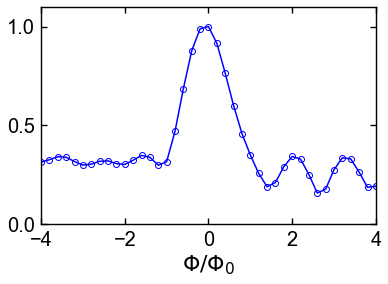

In [145]:
if savecount==0:
    save=True
else:
    save=False
fig=plt.figure(figsize=(6,4))
ax=plt.subplot(111)

ax.plot(pairing_A1['Flux'][0],pairing_A1['I_p'][0]/np.amax(pairing_A1['I_p'][0]),'bo-',markerfacecolor='none',markersize=6,linewidth=1.5)
ax.set_xlabel('$\Phi/\Phi_0$',fontsize=font+2)
ax2.set_ylabel('$I_c^+/I_{c,max}^+$ (nA)',fontsize=font+2)
ax.set_ylim(0,1.1)
ax.set_xlim(-4,4)
#ax2.text(15,54,'$T=35$ mK',fontsize=18)  
ax.tick_params(axis='both', which='major', labelsize=font+1,direction='in')

ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=6,width=1.4)
ax.tick_params(axis='both',which='minor',direction='in',size=3,width=1.4,pad=6)

ax.tick_params(axis='x',which='both', bottom=True,top=True,labelbottom=True)
ax.tick_params(axis='y',which='both', left=True,right=True)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.4)
    
if save:
    plt.savefig(savename+'A1pairing_singlet'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=300) 
    save=False
plt.show()

In [148]:
savecount=0

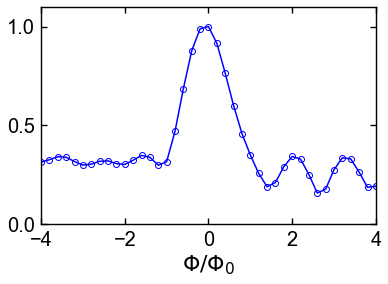

In [149]:


if savecount==0:
    save=True
else:
    save=False
fig=plt.figure(figsize=(6,4))
ax=plt.subplot(111)

ax.plot(pairing_A1_trip['Flux'][0],pairing_A1_trip['I_p'][0]/np.amax(pairing_A1_trip['I_p'][0]),'bo-',markerfacecolor='none',markersize=6,linewidth=1.5)
ax.set_xlabel('$\Phi/\Phi_0$',fontsize=font+2)
ax2.set_ylabel('$I_c^+/I_{c,max}^+$ (nA)',fontsize=font+2)
ax.set_ylim(0,1.1)
ax.set_xlim(-4,4)
#ax2.text(15,54,'$T=35$ mK',fontsize=18)  
ax.tick_params(axis='both', which='major', labelsize=font+1,direction='in')

ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=6,width=1.4)
ax.tick_params(axis='both',which='minor',direction='in',size=3,width=1.4,pad=6)

ax.tick_params(axis='x',which='both', bottom=True,top=True,labelbottom=True)
ax.tick_params(axis='y',which='both', left=True,right=True)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.4)
    
if save:
    plt.savefig(savename+'A1pairing_triple'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=300) 
    save=False
plt.show()

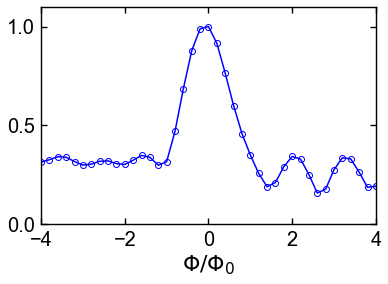

In [151]:


if savecount==0:
    save=True
else:
    save=False
fig=plt.figure(figsize=(6,4))
ax=plt.subplot(111)

ax.plot(pairing_E1['Flux'][0],pairing_E1['I_p'][0]/np.amax(pairing_E1['I_p'][0]),'bo-',markerfacecolor='none',markersize=6,linewidth=1.5)
ax.set_xlabel('$\Phi/\Phi_0$',fontsize=font+2)
ax2.set_ylabel('$I_c^+/I_{c,max}^+$ (nA)',fontsize=font+2)
ax.set_ylim(0,1.1)
ax.set_xlim(-4,4)
#ax2.text(15,54,'$T=35$ mK',fontsize=18)  
ax.tick_params(axis='both', which='major', labelsize=font+1,direction='in')

ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=6,width=1.4)
ax.tick_params(axis='both',which='minor',direction='in',size=3,width=1.4,pad=6)

ax.tick_params(axis='x',which='both', bottom=True,top=True,labelbottom=True)
ax.tick_params(axis='y',which='both', left=True,right=True)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.4)
    
if save:
    plt.savefig(savename+'E1pairing_triple'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=300) 
    save=False
plt.show()

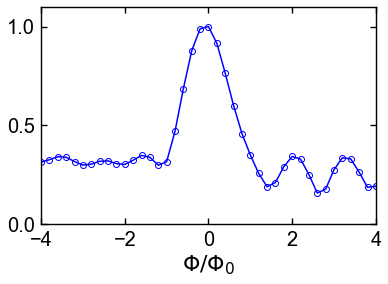

In [152]:


if savecount==0:
    save=True
else:
    save=False
fig=plt.figure(figsize=(6,4))
ax=plt.subplot(111)

ax.plot(pairing_E2['Flux'][0],pairing_E2['I_p'][0]/np.amax(pairing_E2['I_p'][0]),'bo-',markerfacecolor='none',markersize=6,linewidth=1.5)
ax.set_xlabel('$\Phi/\Phi_0$',fontsize=font+2)
ax2.set_ylabel('$I_c^+/I_{c,max}^+$ (nA)',fontsize=font+2)
ax.set_ylim(0,1.1)
ax.set_xlim(-4,4)
#ax2.text(15,54,'$T=35$ mK',fontsize=18)  
ax.tick_params(axis='both', which='major', labelsize=font+1,direction='in')

ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=6,width=1.4)
ax.tick_params(axis='both',which='minor',direction='in',size=3,width=1.4,pad=6)

ax.tick_params(axis='x',which='both', bottom=True,top=True,labelbottom=True)
ax.tick_params(axis='y',which='both', left=True,right=True)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.4)
    
if save:
    plt.savefig(savename+'E2pairing_triple'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=300) 
    save=False
plt.show()

In [46]:
from astropy.convolution import Gaussian1DKernel, convolve, Gaussian2DKernel

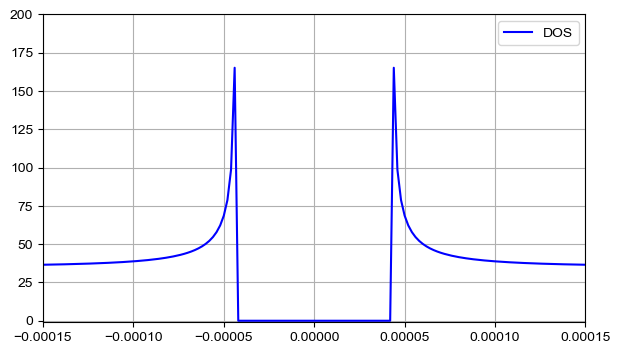

In [47]:
e=1.602E-19
V=np.arange(-0.2E-3,0.2E-3,0.2E-5)
Tsme=np.zeros_like(V)
E=e*V
Delta=43E-6
k=8.61E-5
#k=1.380649E-23
N0=1
T=1
tau=15E-6
Is=35
DOSV=np.zeros_like(V)
for i in range(len(V)):
    Tsme[i]=2*k*T
    if abs(V[i])>Delta:
        DOSV[i]=V[i]
        
def expT(T,V):
    return np.exp(-Delta/(k*T))*np.sqrt(2*np.pi*Delta/(k*T))*np.abs(V)


def Ns(E):
    return Is*(np.abs(E)/np.sqrt(np.abs((E)**2-Delta**2)))/N0


    #return (np.abs(V)/np.sqrt(np.abs(V**2-Delta**2)))/N0*np.sqrt(2*np.pi*Delta/(k*T))
def dIdV(V):
    return Ns(V)*np.exp(-Delta/(k*T))

# convolute with a gaussian, this accounts for the finite temperature
#package used is astropy.convolution
#extend in convolve keeps the boundaries to have the same value as if the extended
#gaussian there is just the same as 

def gaussian(x,nu,s):
    return 1./(s*np.sqrt(2*np.pi))*np.exp(-0.5*np.power(x-nu,2)/np.power(s,2))

c=1

g=Gaussian1DKernel(stddev=c)


#convoluted=convolve(data,g,boundary='extend')
convoluted=convolve(Ns(DOSV),g,boundary='extend')

def Ns_dynes(E):
    return Is*np.real((np.abs(E-1j*tau)/np.sqrt(np.abs((E-1j*tau)**2-Delta**2)))/N0)

convoluted2=np.convolve(Ns_dynes(DOSV),g,mode='same')

plt.figure(figsize=(7,4))
plt.plot(V,Ns(DOSV),'b',label='DOS')
#plt.plot(V,convoluted,'k',label='DOS Thermal')
#plt.plot(V,convoluted2,'r',label='DOS Thermal & Dynes')

#plt.plot(V,g,'r',label='DOS Thermal & Dynes')
#plt.xlabel('V (mV)',fontsize=14)
#plt.ylabel('$I_S$',fontsize=14)
plt.legend()
plt.ylim(-1,200)
plt.xlim(-0.00015,0.00015)
plt.grid()
plt.show()


In [ ]:
Tsme=np.zeros_like(V)
for i in range(len(V)):
    for j in range(len(integral2)):
        Tsme[i]=2*k*T
        if abs(V[i])>integral2[j]:
            DOSV[i,j]=V[i]
convoluted=[]
for i in range(len(DOSV)):
    convoluted.append(convolve(Ns(DOSV)[i],g,boundary='extend'))


In [49]:
V=np.linspace(-1.2,1.2,401)
B=np.linspace(-4,4,601)
DOSV=np.zeros((len(V),len(B)))

def Ns2D_IAsym(V,Icplus,Icminus):

    E=np.zeros((len(V),len(B)))
    data=np.zeros_like((E))
    Tsme=np.zeros_like(V)
    for i in range(len(V)):
        for j in range(len(Icplus)):
            Tsme[i]=2*k*T
            if V[i]>=0:
                if abs(V[i])>Icplus[j]:
                    E[i,j]=V[i]
            elif V[i]<0:
                if abs(V[i])>Icminus[j]:
                    E[i,j]=V[i]

    for i in range(len(V)):
        if V[i]>=0:
            for j in range(len(Icplus)):
                data[i,j]=Is*(np.abs(E[i,j])/np.sqrt(np.abs((E[i,j])**2-Icplus[j]**2)))/N0
        else:
            for j in range(len(Icplus)):
                data[i,j]=Is*(np.abs(E[i,j])/np.sqrt(np.abs((E[i,j])**2-Icminus[j]**2)))/N0
  
    return data

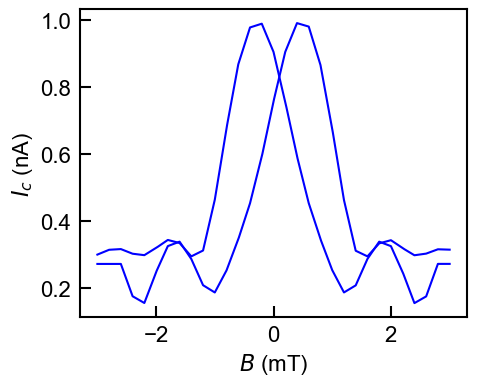

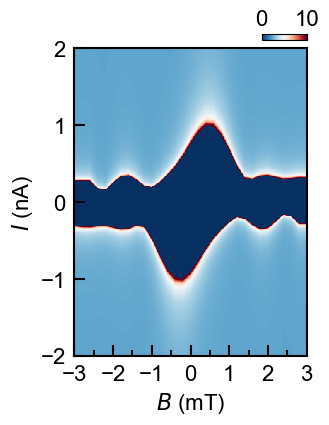

In [80]:
'''
Code to generate the actual integral, which would be the measured Ic(B)
'''
if savecount==0:
    save=True
else:
    save=False
text_true=True
integral=[]

V=np.linspace(-2,2,401)
B=np.linspace(-3,3,601)
#B=mat_fig3d1['Flux'][0]
DOSV=np.zeros((len(V),len(B)))

    
Icplus=np.interp(B-0.4,mat_fig3d1['Flux'][0],mat_fig3d1['I_p'][0]/2.53)
Icminus=np.interp(B+0.2,mat_fig3d1['Flux'][0],mat_fig3d2['I_p'][0]/2.53)

#x2.plot(mat_fig3d1['Flux'][0]+0.8,mat_fig3d1['I_p'][0]/2.53+1,'b-',label='$I_c^+$',markersize=msize)
#x2.plot(mat_fig3d2['Flux'][0]-0.2,mat_fig3d2['I_p'][0]/2.53,'k-',label='$|I_c^-|$',markersize=msize)

'''For the maps'''

# This is an integral in x, so I run everything over B


## Plot the results 
ax=plot_pre(5,4)
ax.plot(B,Icplus,'b')
ax.plot(B,Icminus,'b')
plot_line(ax,leg=False)
#ax.text(40,0.33,r'$\beta_{left}=L(B+)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.3,r'$\beta_{right}=L(B)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.27,r'$\beta_{bulk}=L(B)/\Phi_0$',fontsize=font-2)
#ax.axvline(x=0,linestyle='dashed')
plt.show()

'''Code for the maps'''

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)


fig=plt.figure(figsize=(3,4 ))
ax=fig.add_subplot(111)
im=plt.pcolormesh(B,V,Ns2D_IAsym(V,Icplus,Icminus)/15,cmap='RdBu_r',vmax=10,rasterized=True)

ax.set_ylabel('$I$ (nA)',fontsize=font)
ax.set_xlabel('$B$ (mT)',fontsize=font)  
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')

ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=8,width=1.5)
ax.tick_params(axis='both',which='minor',direction='in',size=4,width=1.5)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
#ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
#ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(50))

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)
if save:
    #plt.savefig(savename+'EdgeBulkAsym_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    #plt.savefig(savename+'EdgeBulkAsym_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    
plt.show()

 ## latest data from Yingming

In [8]:
folder4='C:/jdiez_local/LDQM/g. Manuscript/Yingming_Data/SQUID_data/SQUID_data/'

In [15]:
SQUID=scipy.io.loadmat(folder4+'12_23_insulating_mu_0_775_T_Delta_50.mat')


In [18]:
SQUID

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri Dec 24 00:54:49 2021',
 '__version__': '1.0',
 '__globals__': [],
 'ConPara': array([[(array([[1]], dtype=uint8),)]], dtype=[('tc', 'O')]),
 'Delta': array([[0.1]]),
 'Flux': array([[-3.  , -2.85, -2.7 , -2.55, -2.4 , -2.25, -2.1 , -1.95, -1.8 ,
         -1.65, -1.5 , -1.35, -1.2 , -1.05, -0.9 , -0.75, -0.6 , -0.45,
         -0.3 , -0.15,  0.  ,  0.15,  0.3 ,  0.45,  0.6 ,  0.75,  0.9 ,
          1.05,  1.2 ,  1.35,  1.5 ,  1.65,  1.8 ,  1.95,  2.1 ,  2.25,
          2.4 ,  2.55,  2.7 ,  2.85,  3.  ]]),
 'Flux_temp': array([[3]], dtype=uint8),
 'HamPara': array([[(array([[0.1]]), array([[0.331]]), array([[-0.01]]), array([[0.097]]), array([[-0.5]]), array([[0]], dtype=uint8), array([[-0.8]]), array([[-0.775]]), array([[1.57079633]]), array([[0.0662]]), array([[0.0331]]), array([[1.57079633]]), array([[80]], dtype=uint8), array([[9]], dtype=uint8), array([[0]], dtype=uint8), array([[0]], dtype=uint8), array([[0]], 

In [29]:
%matplotlib inline

In [59]:
savename='C:/jdiez_local/LDQM/g. Manuscript/Figures_2022/'

In [72]:
save=True

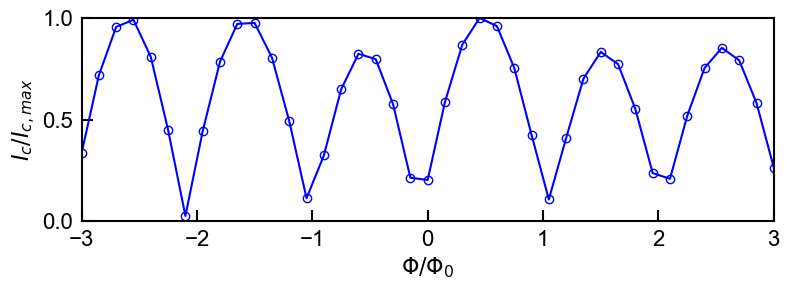

In [73]:
ax=plot_pre(8,3)
ax.plot(SQUID['Flux'][0],SQUID['I_p'][0]/np.amax(SQUID['I_p'][0]),color='b', marker='.', linewidth=1.5, markersize=12, mfc='none')
plot_line(ax,xlabel='$\Phi/\Phi_0$',ylabel='$I_c/I_{c,max}$',leg=False)
ax.set_ylim(0,1)
ax.set_xlim(-3,3)
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
plt.tight_layout()
if save:
    plt.savefig(savename+'Yingming_SQUID'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'Yingming_SQUID'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    

plt.show()